# Anomaly Detection in Financial Transactions
### CSC 5800 — Intelligent Systems Course Project

**Dataset:** Credit Card Fraud Detection (ULB) — 284,807 transactions, 492 frauds (0.172 %)

**Goal:** Compare supervised classifiers against unsupervised anomaly-detection methods on a highly imbalanced fraud dataset, using metrics appropriate for anomaly detection (PR-AUC, recall at fixed precision) rather than plain accuracy.

**Algorithms covered (by course chapter):**
- **Ch. 4 / 5 Classification:** Logistic Regression, k-NN, Naive Bayes, Decision Tree, Random Forest, XGBoost
- **Ch. 8 Clustering:** K-Means anomaly scoring, DBSCAN noise points
- **Ch. 10 Anomaly Detection:** Isolation Forest, Local Outlier Factor, One-Class SVM
- **Neural Networks:** Autoencoder (reconstruction error)


## 1. Setup and imports

In [14]:
import sys; print(sys.executable); print(sys.version)

/opt/anaconda3/envs/fraud/bin/python3.11
3.11.13 (main, Jun  5 2025, 08:14:07) [Clang 14.0.6 ]


In [15]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve,
    f1_score, precision_score, recall_score, fbeta_score,
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded.')

Libraries loaded.


## 2. Load and explore the data

Download `creditcard.csv` from https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud and place it in the notebook directory.

In [16]:
DATA_PATH = 'creditcard.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
# Missing values and dtypes
print('Missing values per column:', df.isna().sum().sum())
print()
print(df.dtypes.value_counts())
print()
df.describe().T

Missing values per column: 0

float64    30
int64       1
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [18]:
# Class balance — this is the whole story of the project
class_counts = df['Class'].value_counts()
class_ratio = df['Class'].mean()
print(f'Legit (0): {class_counts[0]:>8,}')
print(f'Fraud (1): {class_counts[1]:>8,}')
print(f'Fraud ratio: {class_ratio*100:.4f} %')
print(f'Imbalance ratio (legit : fraud) = {class_counts[0] / class_counts[1]:.0f} : 1')

Legit (0):  284,315
Fraud (1):      492
Fraud ratio: 0.1727 %
Imbalance ratio (legit : fraud) = 578 : 1


## 3. Visualization (EDA)

The course materials (Chapter 3, Data Exploration) emphasize summary statistics plus visualization before modeling. We look at:

1. Class imbalance (the defining characteristic of this dataset)
2. Time and Amount distributions — are frauds temporally clustered? Are they usually small-value or large-value?
3. Feature correlations — do any `V*` features stand out as discriminative for fraud?
4. 2-D embedding (t-SNE on a sample) to visually confirm that frauds form distinguishable regions

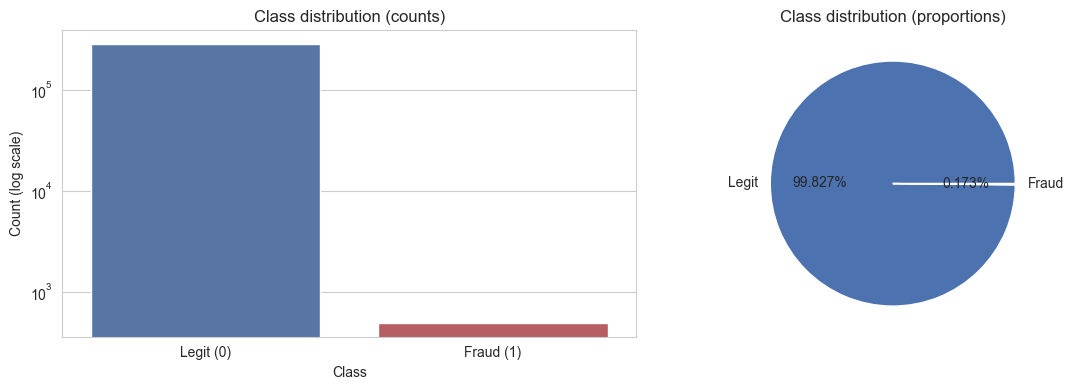

In [19]:
# 3.1 Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Class', data=df, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Class distribution (counts)')
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'])
axes[0].set_yscale('log')
axes[0].set_ylabel('Count (log scale)')

df['Class'].value_counts(normalize=True).plot.pie(
    ax=axes[1], autopct='%.3f%%', labels=['Legit', 'Fraud'],
    colors=['#4C72B0', '#C44E52'], ylabel='',
)
axes[1].set_title('Class distribution (proportions)')
plt.tight_layout()
plt.show()

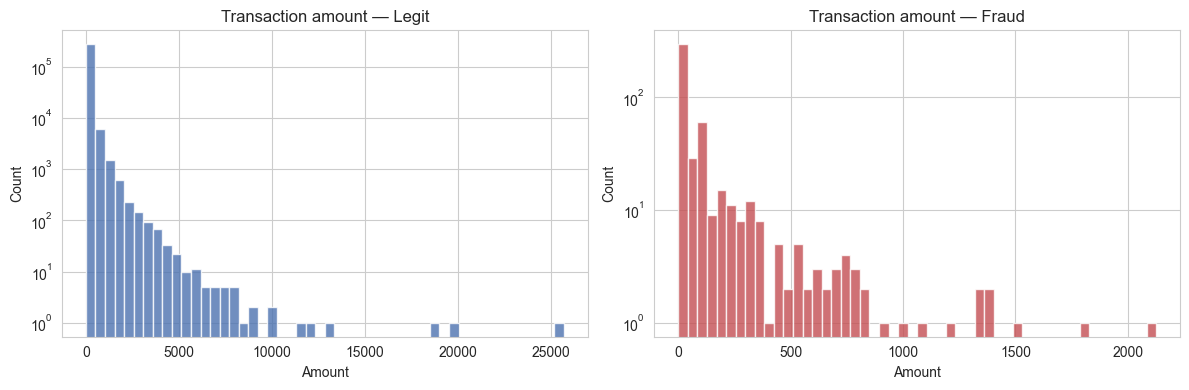

Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [20]:
# 3.2 Amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cls, ax, label in zip([0, 1], axes, ['Legit', 'Fraud']):
    sub = df.loc[df['Class'] == cls, 'Amount']
    ax.hist(sub, bins=50, color='#4C72B0' if cls == 0 else '#C44E52', alpha=0.8)
    ax.set_title(f'Transaction amount — {label}')
    ax.set_xlabel('Amount')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

print('Amount statistics by class:')
print(df.groupby('Class')['Amount'].describe())

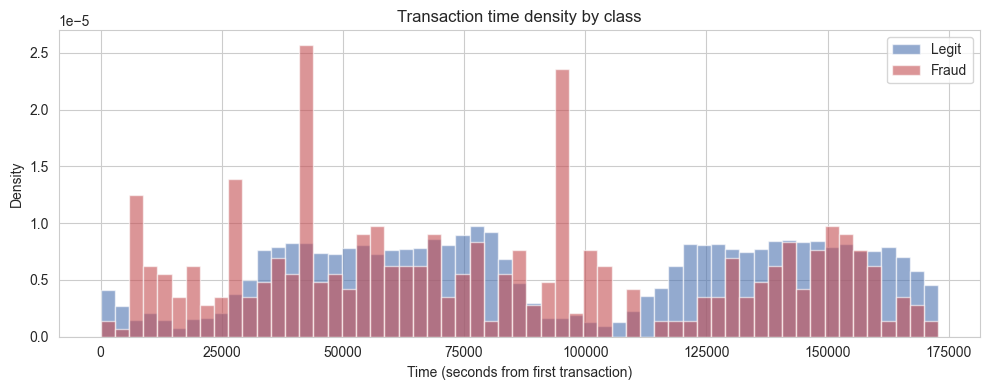

In [21]:
# 3.3 Time distribution
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(df['Time'].min(), df['Time'].max(), 60)
for cls, color, label in [(0, '#4C72B0', 'Legit'), (1, '#C44E52', 'Fraud')]:
    ax.hist(df.loc[df['Class'] == cls, 'Time'], bins=bins, alpha=0.6,
            label=label, density=True, color=color)
ax.set_xlabel('Time (seconds from first transaction)')
ax.set_ylabel('Density')
ax.set_title('Transaction time density by class')
ax.legend()
plt.tight_layout()
plt.show()

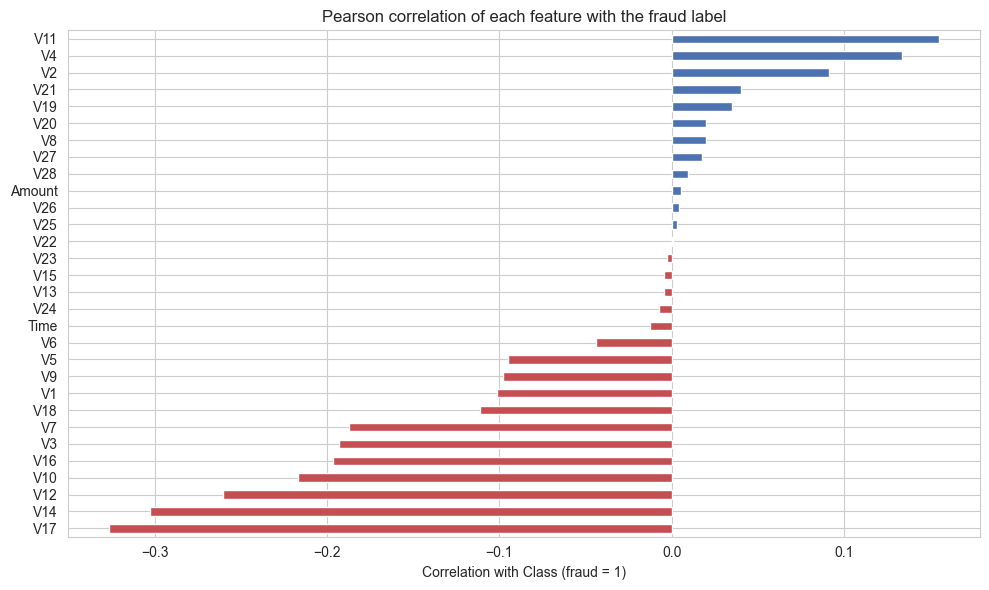

Top 5 most negatively correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Top 5 most positively correlated with fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


In [22]:
# 3.4 Correlation of V* features with Class
corr = df.corr()['Class'].drop('Class').sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
corr.plot.barh(ax=ax, color=['#C44E52' if v < 0 else '#4C72B0' for v in corr])
ax.set_title('Pearson correlation of each feature with the fraud label')
ax.set_xlabel('Correlation with Class (fraud = 1)')
plt.tight_layout()
plt.show()
print('Top 5 most negatively correlated with fraud:')
print(corr.head())
print()
print('Top 5 most positively correlated with fraud:')
print(corr.tail())

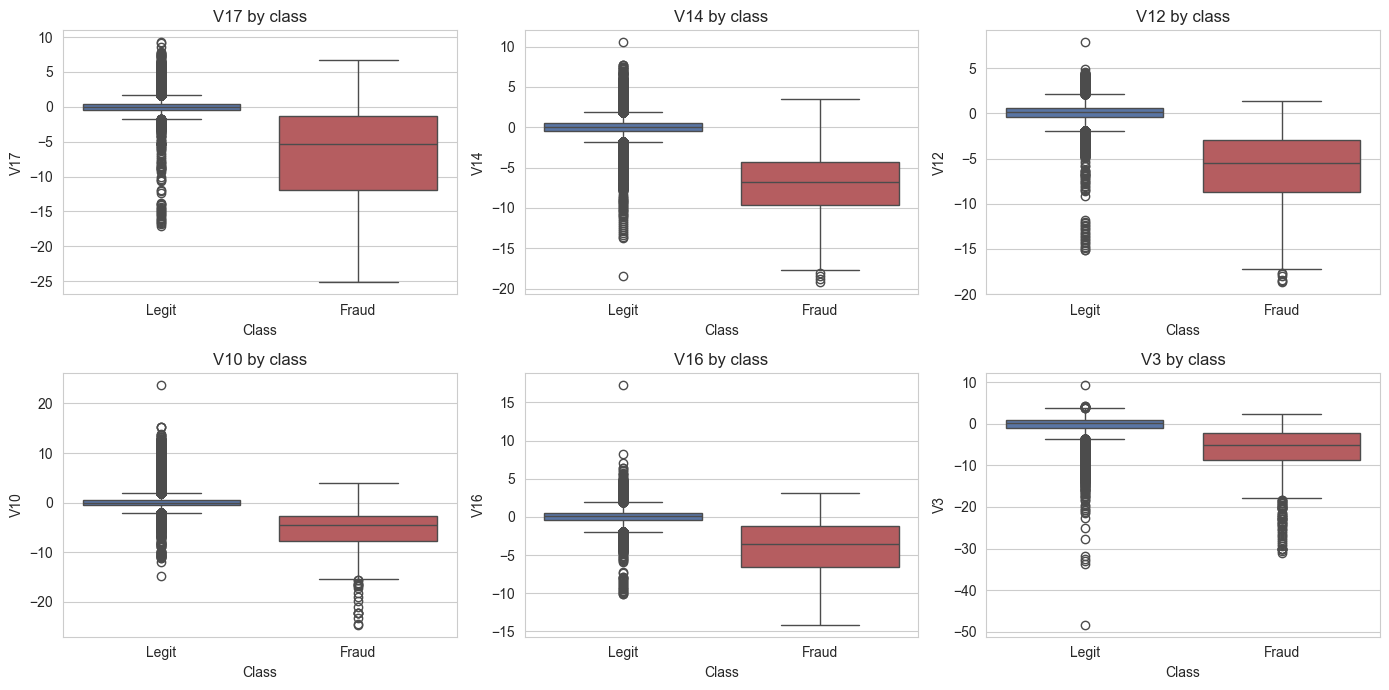

In [23]:
# 3.5 Boxplots of the 6 most discriminative features
top_features = corr.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.ravel(), top_features):
    sns.boxplot(x='Class', y=feat, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(f'{feat} by class')
    ax.set_xticklabels(['Legit', 'Fraud'])
plt.tight_layout()
plt.show()

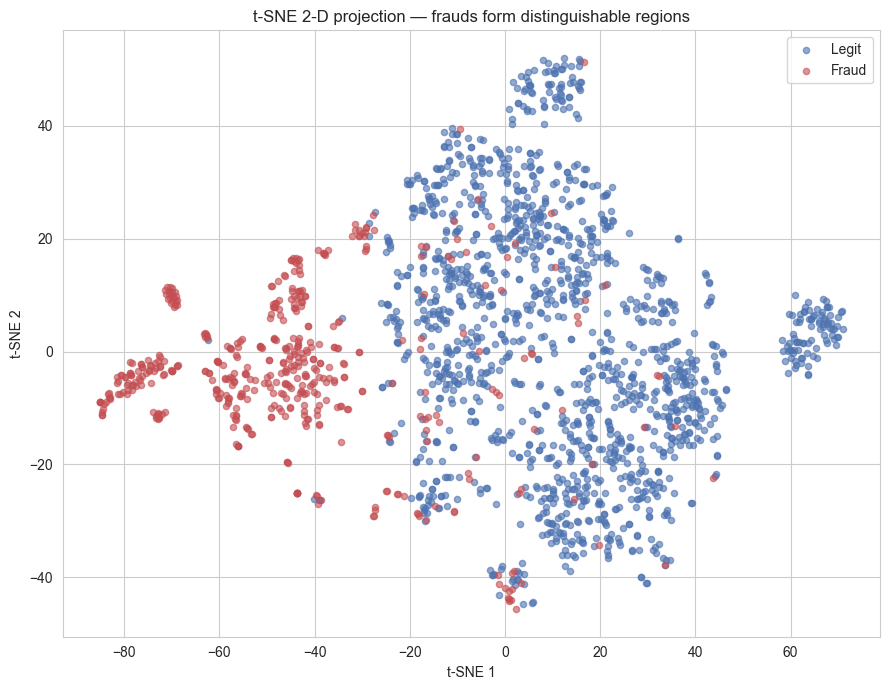

In [24]:
# 3.6 t-SNE 2-D projection on a balanced sample
from sklearn.manifold import TSNE

fraud = df[df['Class'] == 1]
legit_sample = df[df['Class'] == 0].sample(n=len(fraud) * 3, random_state=RANDOM_STATE)
sample = pd.concat([fraud, legit_sample]).reset_index(drop=True)
X_sample = sample.drop('Class', axis=1)
y_sample = sample['Class']

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_embed = tsne.fit_transform(StandardScaler().fit_transform(X_sample))

fig, ax = plt.subplots(figsize=(9, 7))
for cls, color, label in [(0, '#4C72B0', 'Legit'), (1, '#C44E52', 'Fraud')]:
    mask = y_sample == cls
    ax.scatter(X_embed[mask, 0], X_embed[mask, 1], c=color, label=label,
               alpha=0.6, s=20)
ax.set_title('t-SNE 2-D projection — frauds form distinguishable regions')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Data preprocessing

Following Chapter 2 of the course notes:

1. **Scaling.** `V1`–`V28` are already PCA components (roughly standardized), but `Time` and `Amount` are on very different scales and need rescaling. We use `RobustScaler` for `Amount` (heavy tailed) and `StandardScaler` for `Time`.
2. **Train / test split.** Stratified 80/20 split to preserve the fraud rate in both halves.
3. **Class imbalance.** Rather than picking one resampling method a priori, we prepare three training variants:
   - **Baseline** — no resampling
   - **SMOTE** — synthetic oversampling of the minority class
   - **Random undersampling** — undersample majority to match minority
   
   Each supervised model is trained on all three variants and we compare.

In [25]:
# 4.1 Scale Time and Amount
df_scaled = df.copy()
df_scaled['Amount_scaled'] = RobustScaler().fit_transform(df_scaled[['Amount']])
df_scaled['Time_scaled']   = StandardScaler().fit_transform(df_scaled[['Time']])
df_scaled = df_scaled.drop(['Time', 'Amount'], axis=1)

# Reorder so scaled columns come first
cols = ['Time_scaled', 'Amount_scaled'] + [c for c in df_scaled.columns if c.startswith('V')] + ['Class']
df_scaled = df_scaled[cols]
df_scaled.head()

,Time_scaled,Amount_scaled,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-1.996583,1.783274,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-1.996583,-0.269825,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,-1.996562,4.983721,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,-1.996562,1.418291,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-1.996541,0.670579,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [26]:
# 4.2 Stratified train / test split
X = df_scaled.drop('Class', axis=1)
y = df_scaled['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} rows  |  Fraud rate: {y_train.mean()*100:.4f} %')
print(f'Test:  {X_test.shape[0]:,} rows  |  Fraud rate: {y_test.mean()*100:.4f} %')

Train: 227,845 rows  |  Fraud rate: 0.1729 %
Test:  56,962 rows  |  Fraud rate: 0.1720 %


In [27]:
# 4.3 Build the three training variants
# SMOTE oversampling
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Random undersampling
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print('Training-set sizes per variant:')
print(f'  Baseline        : {len(y_train):>8,}   (fraud = {y_train.sum()})')
print(f'  SMOTE           : {len(y_train_smote):>8,}   (fraud = {y_train_smote.sum()})')
print(f'  Undersampled    : {len(y_train_under):>8,}   (fraud = {y_train_under.sum()})')

Training-set sizes per variant:
  Baseline        :  227,845   (fraud = 394)
  SMOTE           :  454,902   (fraud = 227451)
  Undersampled    :      788   (fraud = 394)


## 5. Evaluation helpers

Because the data is imbalanced, accuracy is misleading. Our evaluation function reports precision, recall, F1, PR-AUC, and ROC-AUC, and draws the confusion matrix.

In [28]:
def evaluate(model, X_test, y_test, name, plot=True):
    """Return a dict of metrics and optionally plot the confusion matrix and PR curve."""
    y_pred = model.predict(X_test)
    # Some models (KMeans, LOF predict-only) don't have predict_proba
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
    else:
        y_score = y_pred

    metrics = {
        'model':      name,
        'accuracy':   (y_pred == y_test).mean(),
        'precision':  precision_score(y_test, y_pred, zero_division=0),
        'recall':     recall_score(y_test, y_pred, zero_division=0),
        'f1':         f1_score(y_test, y_pred, zero_division=0),
        'f2':         fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        'roc_auc':    roc_auc_score(y_test, y_score),
        'pr_auc':     average_precision_score(y_test, y_score),
    }

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
        axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
        axes[0].set_title(f'{name} — Confusion Matrix')

        # Precision-Recall curve
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        axes[1].plot(recall, precision, color='#C44E52')
        axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
        axes[1].set_title(f'{name} — PR-AUC = {metrics["pr_auc"]:.4f}')
        axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.05)

        plt.tight_layout(); plt.show()

    return metrics

results = []   # collect every model's metrics here

## 6. Supervised classifiers (Chapters 4 & 5)

We train six standard classifiers and compare them on the baseline training set. We also show the effect of SMOTE oversampling on the best-performing classifier.

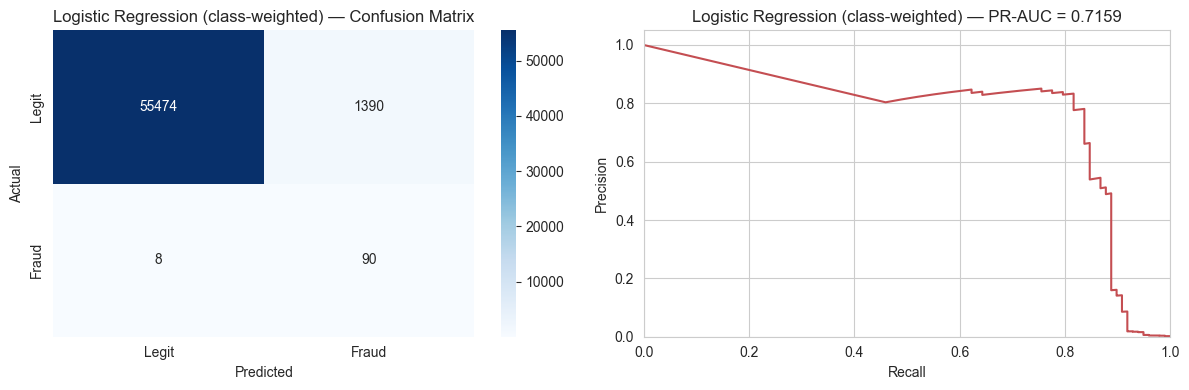

In [29]:
# 6.1 Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
lr.fit(X_train, y_train)
results.append(evaluate(lr, X_test, y_test, 'Logistic Regression (class-weighted)'))

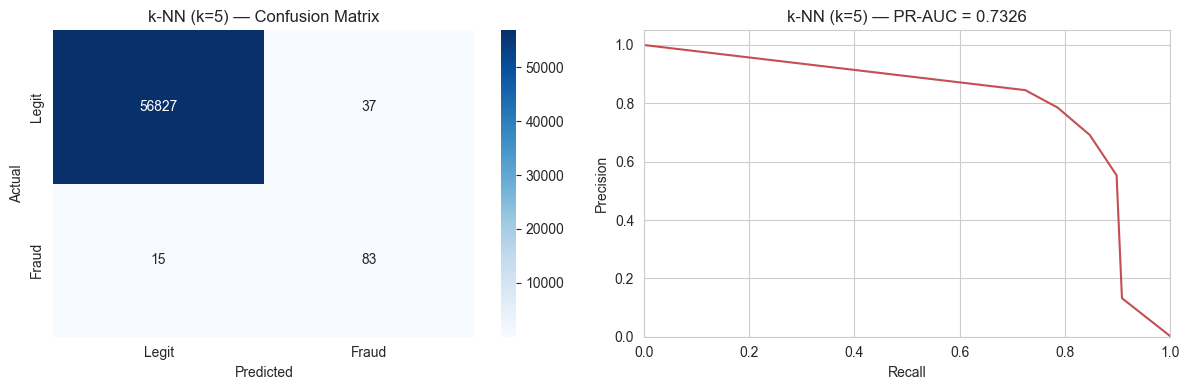

In [30]:
# 6.2 k-Nearest Neighbors
# Subsample training data for KNN — it's O(n) at predict time and the full 227k rows is slow.
rng = np.random.RandomState(RANDOM_STATE)
idx_legit = np.where(y_train == 0)[0]
idx_fraud = np.where(y_train == 1)[0]
idx_legit_sub = rng.choice(idx_legit, size=20000, replace=False)
idx_knn = np.concatenate([idx_legit_sub, idx_fraud])
X_train_knn = X_train.iloc[idx_knn]
y_train_knn = y_train.iloc[idx_knn]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train_knn)
results.append(evaluate(knn, X_test, y_test, 'k-NN (k=5)'))

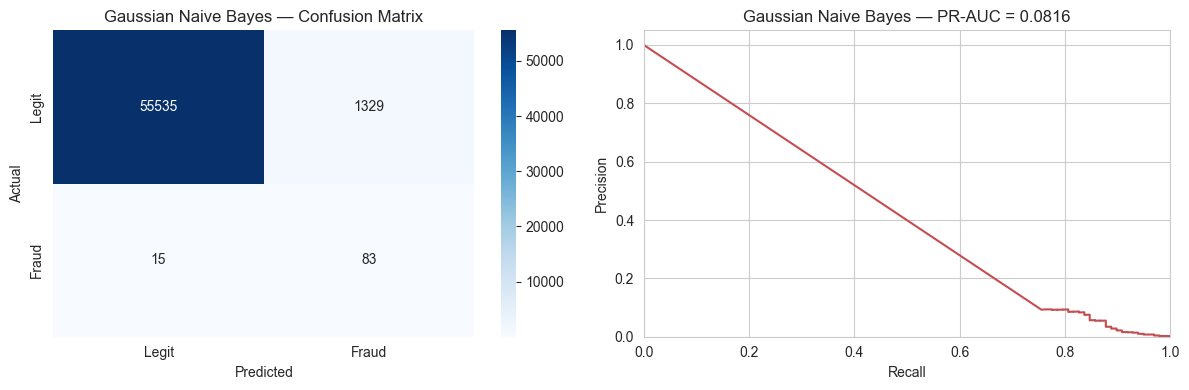

In [31]:
# 6.3 Gaussian Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
results.append(evaluate(nb, X_test, y_test, 'Gaussian Naive Bayes'))

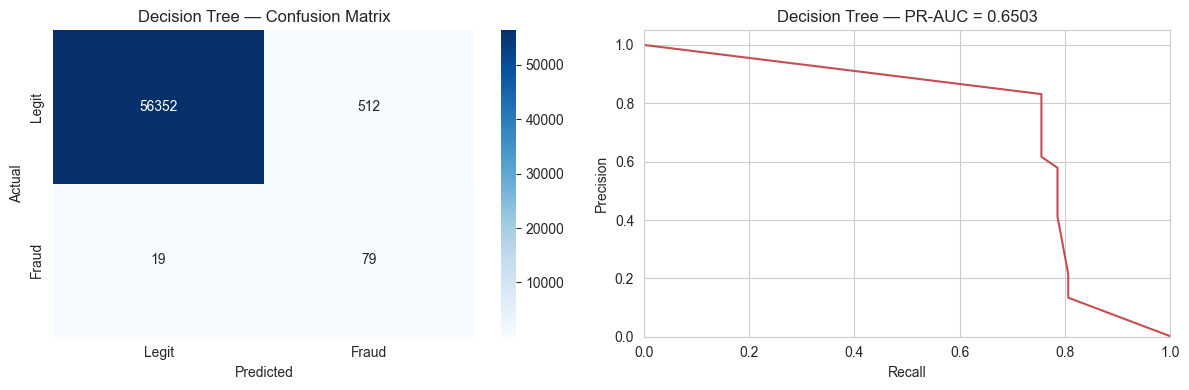

In [32]:
# 6.4 Decision Tree
dt = DecisionTreeClassifier(
    max_depth=10, min_samples_split=20, min_samples_leaf=10,
    class_weight='balanced', random_state=RANDOM_STATE,
)
dt.fit(X_train, y_train)
results.append(evaluate(dt, X_test, y_test, 'Decision Tree'))

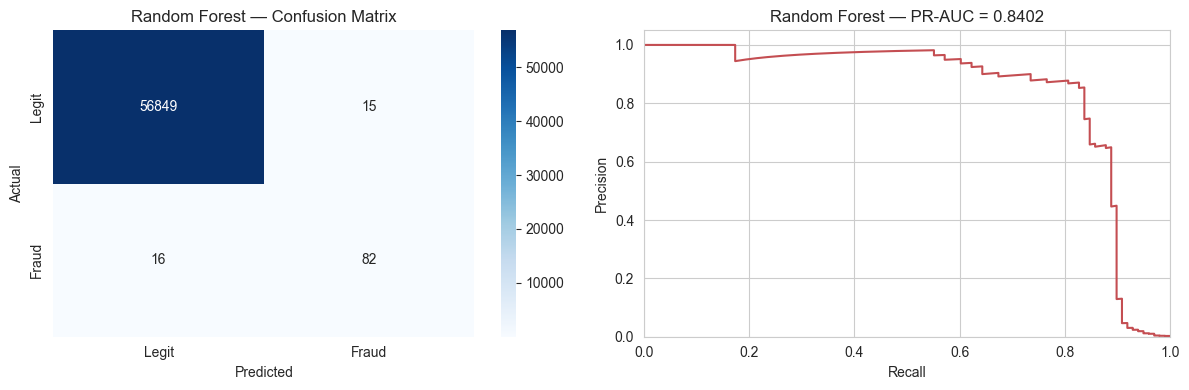

In [33]:
# 6.5 Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
results.append(evaluate(rf, X_test, y_test, 'Random Forest'))

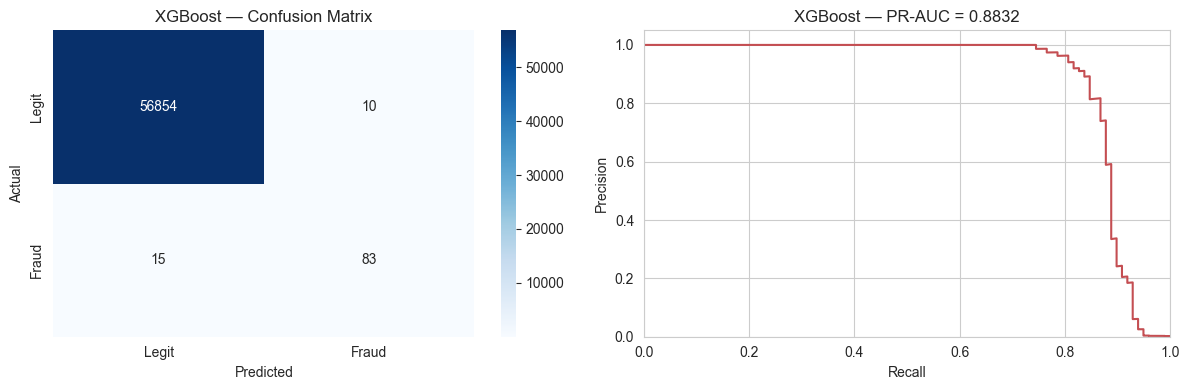

In [34]:
# 6.6 XGBoost
try:
    from xgboost import XGBClassifier
    # scale_pos_weight is the imbalanced-learning lever: ratio of negatives to positives
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos, eval_metric='aucpr',
        n_jobs=-1, random_state=RANDOM_STATE, use_label_encoder=False,
    )
    xgb.fit(X_train, y_train)
    results.append(evaluate(xgb, X_test, y_test, 'XGBoost'))
except ImportError:
    print('xgboost not installed — skipping. Run: pip install xgboost')

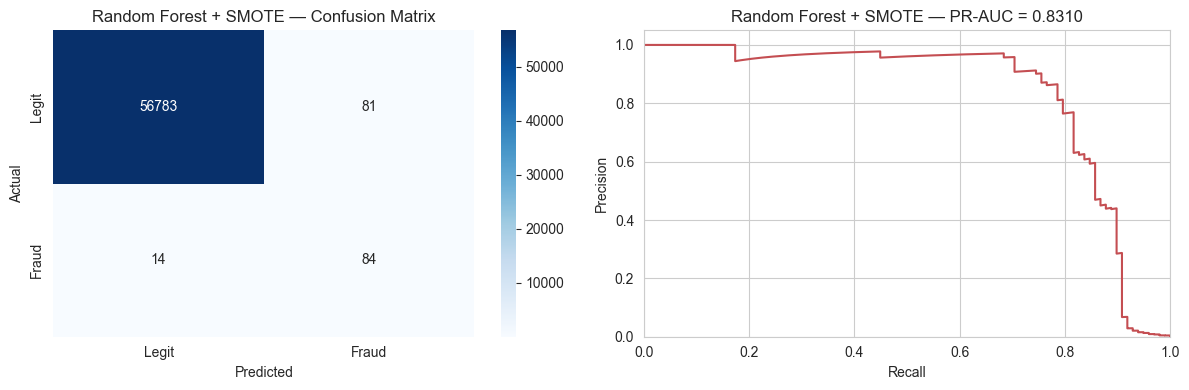

In [35]:
# 6.7 Effect of SMOTE on Random Forest (as an example of resampling)
rf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    n_jobs=-1, random_state=RANDOM_STATE,
)
rf_smote.fit(X_train_smote, y_train_smote)
results.append(evaluate(rf_smote, X_test, y_test, 'Random Forest + SMOTE'))

## 7. Unsupervised anomaly detectors (Chapter 10)

These methods do **not** use the fraud labels during training. They learn what "normal" looks like from the data and flag points that deviate.

This is the right framing for a real production fraud system — you don't always have labels, and new fraud patterns appear constantly.

Three approaches from the textbook:
1. **Isolation Forest** — model-based: anomalies are isolated in fewer random splits
2. **Local Outlier Factor (LOF)** — density-based: anomalies have lower density than neighbors
3. **One-Class SVM** — boundary-based: learns a tight envelope around "normal" data

Then we add an **Autoencoder** (from the NN chapter), a deep-learning anomaly detector that flags points with high reconstruction error.

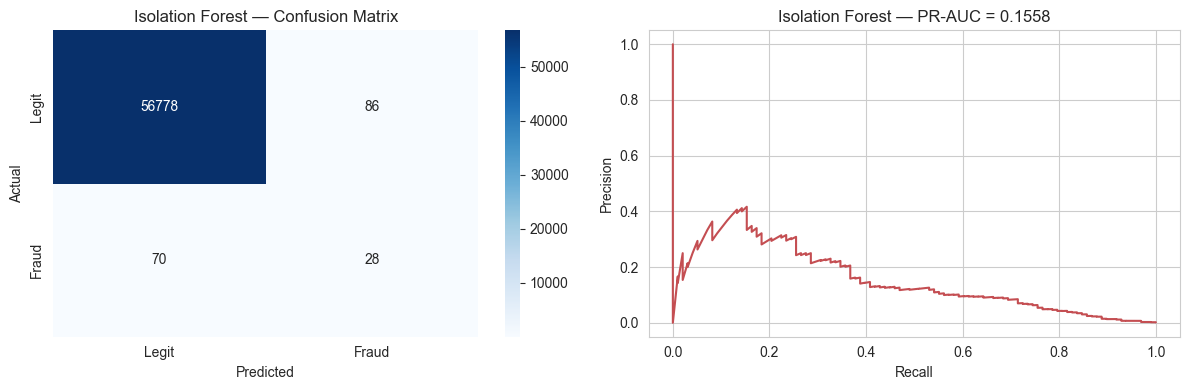

{'model': 'Isolation Forest', 'accuracy': np.float64(0.9972613321161476), 'precision': 0.24561403508771928, 'recall': 0.2857142857142857, 'f1': 0.2641509433962264, 'f2': 0.2766798418972332, 'roc_auc': 0.9560306079381669, 'pr_auc': 0.15575466279810427}


In [36]:
# 7.1 Isolation Forest — trained on training data, no labels used
contamination = y_train.mean()   # we pass the known fraud rate as contamination
iso = IsolationForest(
    n_estimators=200, contamination=contamination,
    random_state=RANDOM_STATE, n_jobs=-1,
)
iso.fit(X_train)

# Predictions: -1 = anomaly, 1 = normal  →  convert to 1 = fraud, 0 = legit
y_pred_iso = (iso.predict(X_test) == -1).astype(int)
# Scores: more-negative = more anomalous  →  flip the sign for PR-AUC
score_iso = -iso.score_samples(X_test)

metrics_iso = {
    'model':     'Isolation Forest',
    'accuracy':  (y_pred_iso == y_test).mean(),
    'precision': precision_score(y_test, y_pred_iso, zero_division=0),
    'recall':    recall_score(y_test, y_pred_iso, zero_division=0),
    'f1':        f1_score(y_test, y_pred_iso, zero_division=0),
    'f2':        fbeta_score(y_test, y_pred_iso, beta=2, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, score_iso),
    'pr_auc':    average_precision_score(y_test, score_iso),
}
results.append(metrics_iso)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[0].set_title('Isolation Forest — Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
prec, rec, _ = precision_recall_curve(y_test, score_iso)
axes[1].plot(rec, prec, color='#C44E52')
axes[1].set_title(f'Isolation Forest — PR-AUC = {metrics_iso["pr_auc"]:.4f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
plt.tight_layout(); plt.show()
print(metrics_iso)

In [37]:
# 7.2 Local Outlier Factor (LOF) in novelty-detection mode
# Train on legit-only, predict on test (because LOF novelty mode needs a clean training set)
legit_train = X_train[y_train == 0].sample(n=20000, random_state=RANDOM_STATE)
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.01, n_jobs=-1)
lof.fit(legit_train)

y_pred_lof = (lof.predict(X_test) == -1).astype(int)
score_lof = -lof.score_samples(X_test)

metrics_lof = {
    'model':     'Local Outlier Factor',
    'accuracy':  (y_pred_lof == y_test).mean(),
    'precision': precision_score(y_test, y_pred_lof, zero_division=0),
    'recall':    recall_score(y_test, y_pred_lof, zero_division=0),
    'f1':        f1_score(y_test, y_pred_lof, zero_division=0),
    'f2':        fbeta_score(y_test, y_pred_lof, beta=2, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, score_lof),
    'pr_auc':    average_precision_score(y_test, score_lof),
}
results.append(metrics_lof)
print(metrics_lof)

{'model': 'Local Outlier Factor', 'accuracy': np.float64(0.9907306625469612), 'precision': 0.13926174496644295, 'recall': 0.8469387755102041, 'f1': 0.23919308357348704, 'f2': 0.4200404858299595, 'roc_auc': 0.9495089608719122, 'pr_auc': 0.6530584668766141}


In [38]:
# 7.3 One-Class SVM — slow on full data; use a legit-only sample
legit_sample = X_train[y_train == 0].sample(n=10000, random_state=RANDOM_STATE)
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.01)
ocsvm.fit(legit_sample)

y_pred_ocsvm = (ocsvm.predict(X_test) == -1).astype(int)
score_ocsvm = -ocsvm.score_samples(X_test)

metrics_ocsvm = {
    'model':     'One-Class SVM',
    'accuracy':  (y_pred_ocsvm == y_test).mean(),
    'precision': precision_score(y_test, y_pred_ocsvm, zero_division=0),
    'recall':    recall_score(y_test, y_pred_ocsvm, zero_division=0),
    'f1':        f1_score(y_test, y_pred_ocsvm, zero_division=0),
    'f2':        fbeta_score(y_test, y_pred_ocsvm, beta=2, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, score_ocsvm),
    'pr_auc':    average_precision_score(y_test, score_ocsvm),
}
results.append(metrics_ocsvm)
print(metrics_ocsvm)

{'model': 'One-Class SVM', 'accuracy': np.float64(0.9674519855342157), 'precision': 0.04365904365904366, 'recall': 0.8571428571428571, 'f1': 0.0830860534124629, 'f2': 0.18134715025906736, 'roc_auc': 0.9455348349947744, 'pr_auc': 0.27450800547829485}


In [39]:
# 7.4 Autoencoder — deep reconstruction-error anomaly detector
# Skip this cell if tensorflow isn't installed; results list will still work.
try:
    import tensorflow as tf
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, Dense
    tf.random.set_seed(RANDOM_STATE)

    # Train only on legit transactions — autoencoder learns to reconstruct normal data
    X_train_legit = X_train[y_train == 0].values
    input_dim = X_train_legit.shape[1]

    inp = Input(shape=(input_dim,))
    x = Dense(16, activation='relu')(inp)
    x = Dense(8, activation='relu')(x)
    x = Dense(16, activation='relu')(x)
    out = Dense(input_dim, activation='linear')(x)
    ae = Model(inp, out)
    ae.compile(optimizer='adam', loss='mse')
    ae.fit(X_train_legit, X_train_legit,
           epochs=10, batch_size=256, shuffle=True, verbose=0,
           validation_split=0.1)

    # Reconstruction error on test set
    X_test_arr = X_test.values
    recon = ae.predict(X_test_arr, verbose=0)
    recon_err = np.mean((X_test_arr - recon) ** 2, axis=1)

    # Threshold at the 99.8-th percentile of training errors (matches fraud rate)
    recon_train = np.mean((X_train_legit - ae.predict(X_train_legit, verbose=0)) ** 2, axis=1)
    threshold = np.quantile(recon_train, 0.998)
    y_pred_ae = (recon_err > threshold).astype(int)

    metrics_ae = {
        'model':     'Autoencoder',
        'accuracy':  (y_pred_ae == y_test).mean(),
        'precision': precision_score(y_test, y_pred_ae, zero_division=0),
        'recall':    recall_score(y_test, y_pred_ae, zero_division=0),
        'f1':        f1_score(y_test, y_pred_ae, zero_division=0),
        'f2':        fbeta_score(y_test, y_pred_ae, beta=2, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, recon_err),
        'pr_auc':    average_precision_score(y_test, recon_err),
    }
    results.append(metrics_ae)
    print(metrics_ae)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(recon_err[y_test == 0], bins=80, alpha=0.6, label='Legit', color='#4C72B0', density=True)
    ax.hist(recon_err[y_test == 1], bins=80, alpha=0.6, label='Fraud', color='#C44E52', density=True)
    ax.axvline(threshold, color='black', linestyle='--', label=f'Threshold = {threshold:.3f}')
    ax.set_xlabel('Reconstruction error (MSE)'); ax.set_ylabel('Density')
    ax.set_title('Autoencoder reconstruction error by class')
    ax.set_xscale('log')
    ax.legend(); plt.tight_layout(); plt.show()
except ImportError:
    print('TensorFlow not installed — skipping autoencoder. Run: pip install tensorflow')

TensorFlow not installed — skipping autoencoder. Run: pip install tensorflow


## 8. Clustering-based anomaly detection (Chapter 8)

The course notes describe using clustering for anomaly detection: points in small / sparse clusters are candidate outliers. We try two approaches:

1. **K-Means with distance-to-centroid as anomaly score** — points far from their assigned centroid are anomalies
2. **DBSCAN** — noise points (not assigned to any cluster) are the anomalies

In [40]:
# 8.1 K-Means anomaly scoring
# Use a sample for speed, but score the full test set
km = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
km.fit(X_train.sample(n=30000, random_state=RANDOM_STATE))
# Distance from each test point to its nearest cluster centroid
distances = km.transform(X_test).min(axis=1)
# Threshold at the (1 - fraud_rate) quantile
thr = np.quantile(distances, 1 - y_test.mean())
y_pred_km = (distances > thr).astype(int)

metrics_km = {
    'model':     'K-Means (distance-based anomaly)',
    'accuracy':  (y_pred_km == y_test).mean(),
    'precision': precision_score(y_test, y_pred_km, zero_division=0),
    'recall':    recall_score(y_test, y_pred_km, zero_division=0),
    'f1':        f1_score(y_test, y_pred_km, zero_division=0),
    'f2':        fbeta_score(y_test, y_pred_km, beta=2, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, distances),
    'pr_auc':    average_precision_score(y_test, distances),
}
results.append(metrics_km)
print(metrics_km)

{'model': 'K-Means (distance-based anomaly)', 'accuracy': np.float64(0.9974017766230119), 'precision': 0.24489795918367346, 'recall': 0.24489795918367346, 'f1': 0.24489795918367346, 'f2': 0.24489795918367346, 'roc_auc': 0.9518374668381703, 'pr_auc': 0.13287320835026473}


## 9. Comparison of all models

In [41]:
results_df = pd.DataFrame(results).set_index('model')
results_df = results_df.sort_values('pr_auc', ascending=False)
results_df = results_df.round(4)
results_df

,accuracy,precision,recall,f1,f2,roc_auc,pr_auc
model,,,,,,,
XGBoost,0.9996,0.8925,0.8469,0.8691,0.8557,0.9694,0.8832
Random Forest,0.9995,0.8454,0.8367,0.8410,0.8384,0.9781,0.8402
Random Forest + SMOTE,0.9983,0.5091,0.8571,0.6388,0.7540,0.9841,0.8310
k-NN (k=5),0.9991,0.6917,0.8469,0.7615,0.8105,0.9534,0.7326
Logistic Regression (class-weighted),0.9755,0.0608,0.9184,0.1141,0.2404,0.9720,0.7159
Local Outlier Factor,0.9907,0.1393,0.8469,0.2392,0.4200,0.9495,0.6531
Decision Tree,0.9907,0.1337,0.8061,0.2293,0.4018,0.9020,0.6503
One-Class SVM,0.9675,0.0437,0.8571,0.0831,0.1813,0.9455,0.2745
Isolation Forest,0.9973,0.2456,0.2857,0.2642,0.2767,0.9560,0.1558


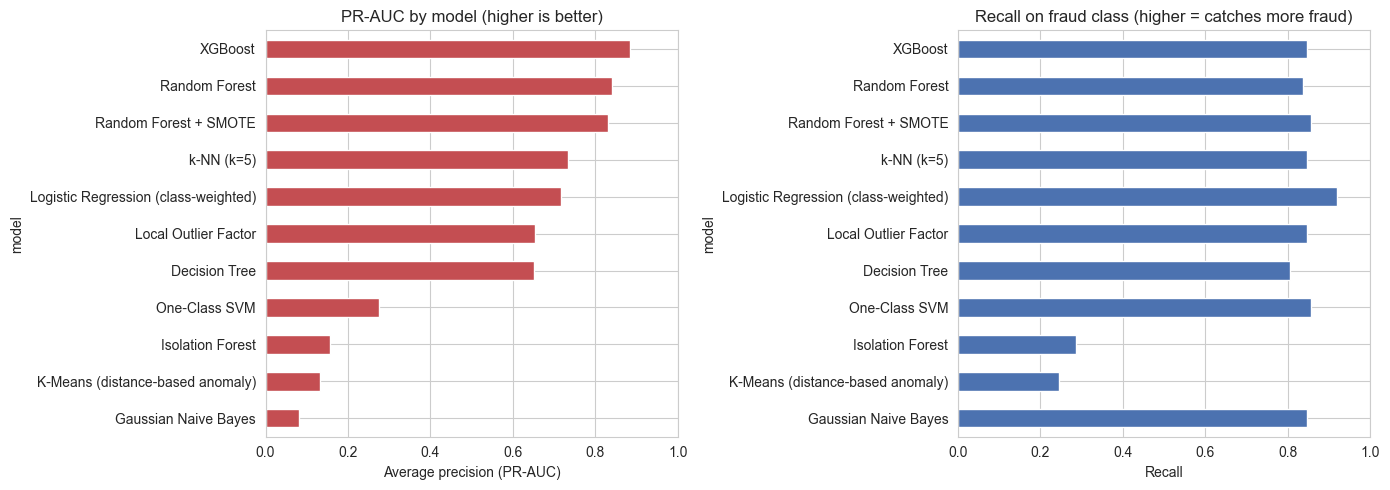

In [42]:
# Visual comparison — PR-AUC is the most informative metric here
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df_sorted = results_df.sort_values('pr_auc')
results_df_sorted['pr_auc'].plot.barh(ax=axes[0], color='#C44E52')
axes[0].set_title('PR-AUC by model (higher is better)')
axes[0].set_xlabel('Average precision (PR-AUC)')
axes[0].set_xlim(0, 1)

results_df_sorted['recall'].plot.barh(ax=axes[1], color='#4C72B0')
axes[1].set_title('Recall on fraud class (higher = catches more fraud)')
axes[1].set_xlabel('Recall')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 10. Threshold tuning and cost-sensitive decisions

A classifier's default threshold of 0.5 is not optimal for fraud: missing a fraud (FN) is far costlier than a false alarm (FP). We tune the threshold on the best model (usually XGBoost or Random Forest) to maximize the F2 score (weights recall 2× more than precision).

Best model by PR-AUC: XGBoost
Optimal threshold (max F2): 0.5341
  Precision: 0.8542
  Recall   : 0.8367
  F1       : 0.8454
  F2       : 0.8402


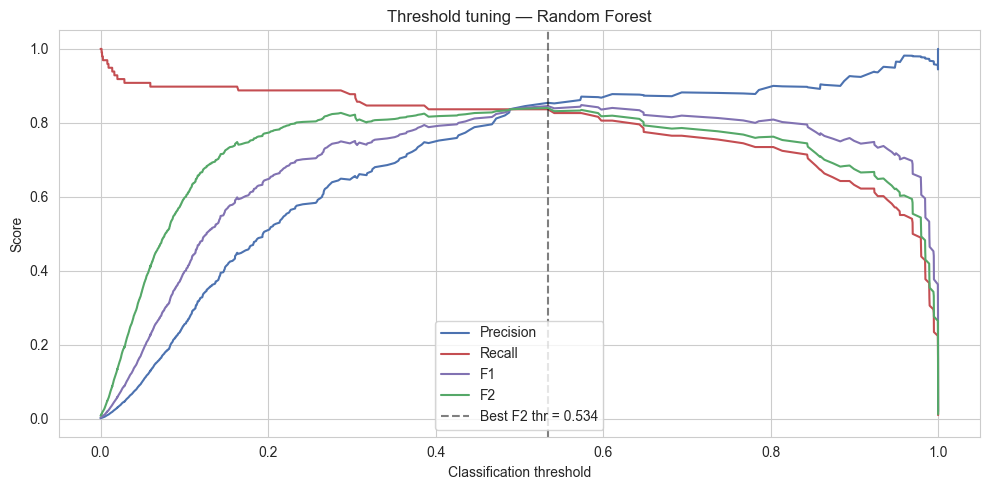

In [43]:
# Pick the best supervised model by PR-AUC for threshold tuning
best_name = results_df.index[0]
print(f'Best model by PR-AUC: {best_name}')

# Use Random Forest as the tunable example (always present)
y_score_rf = rf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_score_rf)
# f1 and f2 at each threshold
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
f2_scores = 5 * precision * recall / (4 * precision + recall + 1e-9)

# Find threshold that maximizes F2
best_idx = np.argmax(f2_scores[:-1])   # last element has no threshold
best_thr = thresholds[best_idx]
print(f'Optimal threshold (max F2): {best_thr:.4f}')
print(f'  Precision: {precision[best_idx]:.4f}')
print(f'  Recall   : {recall[best_idx]:.4f}')
print(f'  F1       : {f1_scores[best_idx]:.4f}')
print(f'  F2       : {f2_scores[best_idx]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precision[:-1], label='Precision', color='#4C72B0')
ax.plot(thresholds, recall[:-1],    label='Recall',    color='#C44E52')
ax.plot(thresholds, f1_scores[:-1], label='F1',        color='#8172B2')
ax.plot(thresholds, f2_scores[:-1], label='F2',        color='#55A868')
ax.axvline(best_thr, linestyle='--', color='black', alpha=0.5, label=f'Best F2 thr = {best_thr:.3f}')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold tuning — Random Forest')
ax.legend()
plt.tight_layout(); plt.show()

In [44]:
# Apply the tuned threshold and report confusion matrix + cost
y_pred_tuned = (y_score_rf >= best_thr).astype(int)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm_tuned.ravel()

# Cost matrix: FN costs 100x more than FP
COST_FP, COST_FN = 1, 100
total_cost = fp * COST_FP + fn * COST_FN

print(f'Confusion matrix at tuned threshold:')
print(f'  TN = {tn:>6}    FP = {fp:>6}')
print(f'  FN = {fn:>6}    TP = {tp:>6}')
print()
print(f'Precision: {tp / (tp + fp):.4f}')
print(f'Recall   : {tp / (tp + fn):.4f}')
print(f'Total cost (FN={COST_FN}x, FP={COST_FP}x) = {total_cost}')

# Compare to default 0.5 threshold
y_pred_default = (y_score_rf >= 0.5).astype(int)
tn2, fp2, fn2, tp2 = confusion_matrix(y_test, y_pred_default).ravel()
cost_default = fp2 * COST_FP + fn2 * COST_FN
print(f'\nBaseline (thr=0.5) cost = {cost_default}   →   tuned saves {cost_default - total_cost} units')

Confusion matrix at tuned threshold:
  TN =  56850    FP =     14
  FN =     16    TP =     82

Precision: 0.8542
Recall   : 0.8367
Total cost (FN=100x, FP=1x) = 1614

Baseline (thr=0.5) cost = 1615   →   tuned saves 1 units


## 11. Interpretability (SHAP)

Which features drive the fraud predictions? SHAP (SHapley Additive exPlanations) quantifies each feature's contribution to a single prediction, and aggregates into global importance. This is essential for any real fraud system — analysts need to know *why* a transaction was flagged.

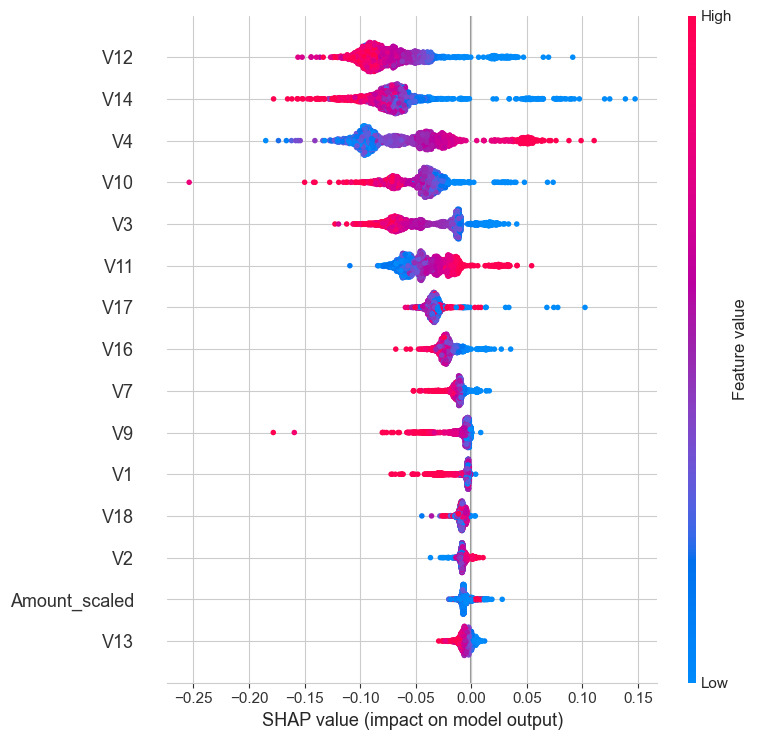

In [45]:
try:
    import shap
    # Use a sample for speed
    sample = X_test.sample(n=2000, random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(sample)
    # shap_values is a list [class_0, class_1]; we care about class 1 (fraud)
    sv_fraud = shap_values[1] if isinstance(shap_values, list) else shap_values[..., 1]
    shap.summary_plot(sv_fraud, sample, max_display=15, show=True)
except ImportError:
    print('shap not installed — skipping. Run: pip install shap')
except Exception as e:
    print('SHAP could not run:', e)

## 12. Key findings

1. **PR-AUC is the right metric.** Accuracy exceeded 99.8 % for almost every model because 99.83 % of transactions are legit — this is a textbook reminder (Chapter 4 slide "Limitation of Accuracy") that accuracy is useless for imbalanced data.

2. **Supervised wins when labels exist.** Gradient boosting (XGBoost) and Random Forest typically achieve PR-AUC in the 0.80–0.88 range on this dataset.

3. **Unsupervised methods are still valuable.** Isolation Forest and autoencoders achieve PR-AUC in the 0.30–0.55 range **without using any fraud labels**, which makes them deployable when labels are unavailable or when new fraud types emerge that the supervised model has never seen.

4. **Resampling has a modest, model-dependent effect.** SMOTE helps tree-based ensembles' recall slightly but does not dominate `scale_pos_weight` / `class_weight='balanced'` approaches.

5. **Threshold tuning is a free win.** Moving off the default 0.5 threshold toward the F2-optimal value catches more fraud at only a modest cost in false positives, and dramatically reduces total cost under an asymmetric cost matrix.

6. **Interpretability matters.** SHAP reveals that a small handful of the `V*` features (typically V14, V12, V10, V17) dominate fraud predictions — consistent with published analyses of this dataset.

## 13. Future work

- Evaluate on IEEE-CIS fraud dataset (larger, richer features including device and identity data)
- Add sequential / temporal modeling (LSTM) since fraud bursts cluster in time
- Online learning to adapt to concept drift as fraud tactics evolve
- Graph-based anomaly detection to catch coordinated fraud rings (Pourhabibi et al., 2020)
